In [32]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

import warnings
warnings.simplefilter("ignore")

In [33]:
# downloading the data from Kaggle

# import kagglehub

# Download latest version
# path = kagglehub.dataset_download("basilb2s/language-detection")

# print("Path to dataset files:", path)

In [34]:
data = pd.read_csv("Language Detection.csv")

data.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [35]:
# Split the data into features and target variable

X = data['Text']
y = data['Language']

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

le.classes_

array(['Arabic', 'Danish', 'Dutch', 'English', 'French', 'German',
       'Greek', 'Hindi', 'Italian', 'Kannada', 'Malayalam', 'Portugeese',
       'Russian', 'Spanish', 'Sweedish', 'Tamil', 'Turkish'], dtype=object)

In [37]:
# Preprocess the text data

data_list = []
for text in X:
    text = re.sub(r'[!@#$(),\n"%^*?\:;~`0-9.]', ' ', text)
    text = re.sub(r'[[]]', ' ', text)
    text = text.lower()
    data_list.append(text)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data_list, y, test_size=0.2, random_state=42)

In [39]:
# convert the text data into numerical features using CountVectorizer
# this will allow for better performance of the model as it will be able to learn from the frequency of words in the text data

from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
cv.fit(X_train)

x_train = cv.transform(X_train).toarray()
x_test  = cv.transform(X_test).toarray()

In [40]:
# now we will train a Naive Bayes model on the training data and evaluate its performance on the test data
# Naive Bayes is a simple and effective algorithm for text classification tasks, and it works well for language detection as well.

from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](17,)","[430.,355.,435.,...,543.,382.,369.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](17,)","[-2.96,-3.15,-2.94,...,-2.72,-3.07,-3.11]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](17,)","[ 0, 1, 2,...,14,15,16]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](17, 34339)","[[ 0., 0., 0.,..., 0., 0., 0.], [ 0., 0., 0.,..., 0., 0., 0.], [ 0.,29., 1.,..., 0., 0., 0.], ..., [ 0., 0., 0.,..., 0., 0., 0.], [ 0., 0., 0.,..., 0., 0., 0.], [ 0., 0., 0.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](17, 34339)","[[-10.63,-10.63,-10.63,...,-10.63,-10.63,-10.63], [-10.6 ,-10.6 ,-10.6 ,...,-10.6 ,-10.6 ,-10.6 ], [-10.64, -7.24, -9.94,...,-10.64,-10.64,-10.64], ..., [-10.7 ,-10.7 ,-10.7 ,...,-10.7 ,-10.7 ,-10.7 ], [-10.57,-10.57,-10.57,...,-10.57,-10.57,-10.57], [-10.56,-10.56,-10.56,...,-10.56,-10.56,-10.56]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34339


In [41]:
import sklearn.metrics as metrics
print(dir(metrics))

['ConfusionMatrixDisplay', 'DetCurveDisplay', 'DistanceMetric', 'PrecisionRecallDisplay', 'PredictionErrorDisplay', 'RocCurveDisplay', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_base', '_classification', '_dist_metrics', '_pairwise_distances_reduction', '_pairwise_fast', '_plot', '_ranking', '_regression', '_scorer', 'accuracy_score', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'auc', 'average_precision_score', 'balanced_accuracy_score', 'brier_score_loss', 'calinski_harabasz_score', 'check_scoring', 'class_likelihood_ratios', 'classification_report', 'cluster', 'cohen_kappa_score', 'completeness_score', 'confusion_matrix', 'confusion_matrix_at_thresholds', 'consensus_score', 'coverage_error', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'd2_pinball_score', 'd2_tweedie_score', 'davies_bouldin_score', 'dcg_score', 'det_curve', 'euclidean_distances', 'explained_variance_s

In [42]:
y_pred = model.predict(x_test)

from sklearn.metrics import RocCurveDisplay, accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)


print("Accuracy is :",accuracy)
print("Confusion Matrix is :\n",cm)
print("Classification Report is :\n",cr)

Accuracy is : 0.9821083172147002
Confusion Matrix is :
 [[104   0   0   2   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0  71   0   1   1   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0 108   2   0   0   0   0   0   0   0   0   0   1   0   0   0]
 [  0   0   0 291   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   1 217   0   0   0   0   0   0   0   0   1   0   0   0]
 [  0   1   0   2   0  90   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   2   0   0  66   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  10   0   0   0   0   0   0   0   0   0]
 [  0   0   0   1   0   0   0   0 144   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  66   0   0   0   0   0   0   0]
 [  0   0   0   2   0   0   0   0   0   0 119   0   0   0   0   0   0]
 [  0   0   0   3   0   0   0   0   0   0   0 141   0   0   0   0   0]
 [  0   0   0   2   0   0   0   0   0   0   0   0 134   0   0   0   0]
 [  0   0   0   3   0

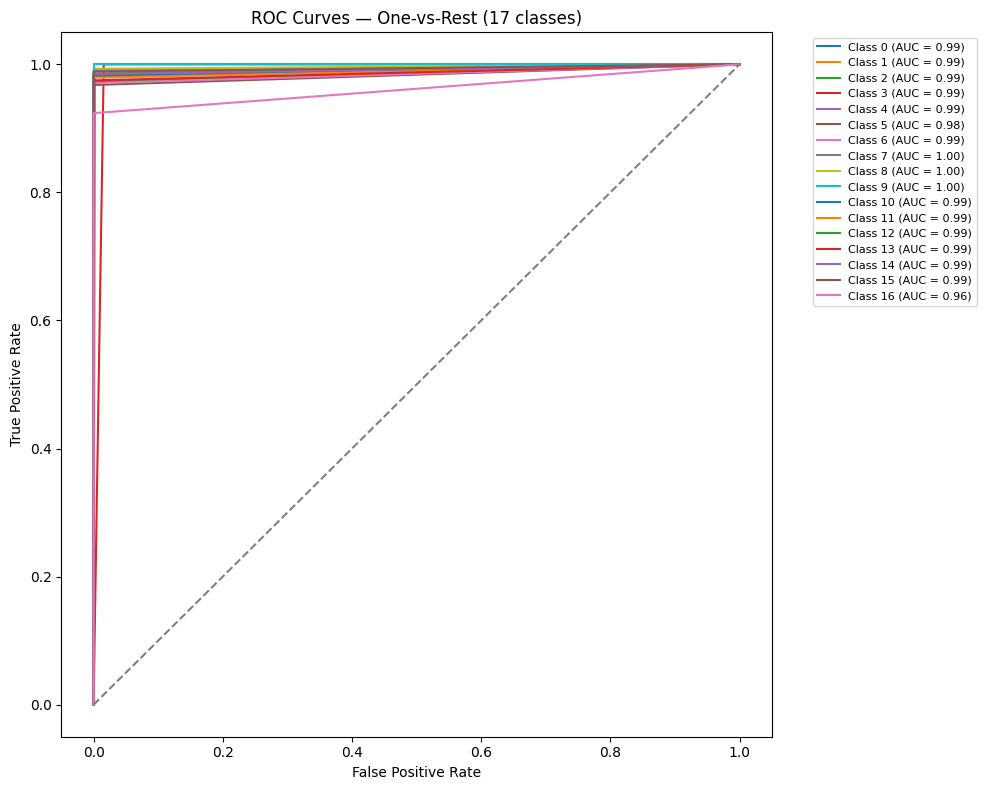

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


 # ROC Curve for multi-class classification using One-vs-Rest approach
 # this will allow us to visualize the performance of the model for each class and compare them.
 # all classes appear to be performing well with AUC scores above 0.9, indicating that the model is able to distinguish between the classes effectively.


classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_bin = label_binarize(y_pred, classes=classes)

plt.figure(figsize=(10, 8))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest (17 classes)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()